# 复现 Fig. 9：暗物质晕的质量吸积史

这个 Notebook 负责论文 Fig. 9 的具体参数、绘图和数据导出，并比较两种质量吸积史：

- `halohistory.calculate_mass_accretion_tracks`：保留原来的 Ludlow16/Appendix C 结果；
- `haloconcentration.mass_accretion_history(..., model="prada12_hmf_sigma")`：使用新的 Prada12 浓度重新计算 $C(M_0,0)$、$\alpha$、$\beta$ 和 $M(z)$；
- 本 Notebook：选择 Fig. 9 的红移网格和 13 个 $M_0$，分别绘图并导出 CSV。

这样调整图例、坐标轴或图片大小时，不会改动主体物理模块。

## 1. 导入模块并定位项目目录

下面同时兼容从项目根目录或 `notebooks` 目录启动 Notebook 的情况。

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "halohistory.py").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import haloconcentration as hc
import halohistory as hh

PROJECT_ROOT

WindowsPath('D:/pbh formation/pbh merge/2body channel and numerical simulation')

## 2. 设置 Fig. 9 的红移和现今质量

原图使用 $z=0$ 加上 49 个正红移点，一直到 $z=12$。$z=0$ 对保存完整质量轨迹很重要，但对数横轴不能显示零，因此绘图时只选取 `z > 0` 的点。

`PRESENT_DAY_MASSES_MSUN` 包含 $10^3,10^4,\ldots,10^{15} M_\odot$，每一行始终代表同一个今天质量 $M_0$ 的历史，不能在不同红移处重新排序。

In [2]:
redshift = np.linspace(0.0, 12.0, 50)
present_day_masses_msun = hh.PRESENT_DAY_MASSES_MSUN
positive_redshift = redshift > 0.0

present_day_masses_msun

array([1.e+03, 1.e+04, 1.e+05, 1.e+06, 1.e+07, 1.e+08, 1.e+09, 1.e+10,
       1.e+11, 1.e+12, 1.e+13, 1.e+14, 1.e+15])

## 3. 计算原有 Ludlow16 的 $M(z)$

返回的 `mass_tracks_msun` 是二维数组：

- 行：13 个不同的现今质量 $M_0$；
- 列：50 个红移点；
- 元素：对应晕在该红移时的质量，单位为 $M_\odot$。

In [3]:
mass_tracks_msun = hh.calculate_mass_accretion_tracks(
    redshift,
    present_day_masses_msun=present_day_masses_msun,
    model="ludlow16",
)

print(f"质量轨迹数组形状：{mass_tracks_msun.shape}")

# 展示 M0=10^3、10^9、10^15 M_sun 三条轨迹在 z=0、约 6 和 12 的值。
mass_tracks_msun[[0, 6, 12]][:, [0, 24, 49]]

质量轨迹数组形状：(13, 50)


array([[1.00000000e+03, 2.15621323e+02, 3.80603708e+01],
       [1.00000000e+09, 8.53135941e+07, 5.26849207e+06],
       [1.00000000e+15, 4.54819070e+11, 1.08619032e+08]])

## 4. 绘制并保存 Ludlow16 Fig. 9

横轴和纵轴都使用对数尺度。13 条曲线循环使用四种线型，图例中的指数来自每条轨迹的现今质量 $M_0$。

图片已保存：D:\pbh formation\pbh merge\2body channel and numerical simulation\fig9_reproduction.png


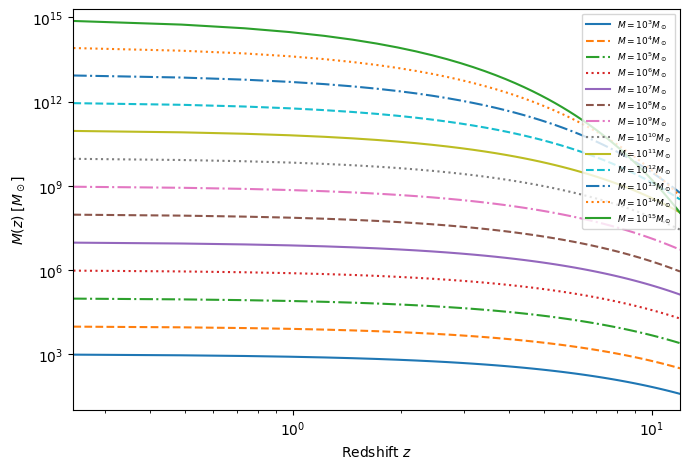

In [4]:
figure, axis = plt.subplots(figsize=(7.0, 4.8))
line_styles = ("-", "--", "-.", ":")

for index, mass0_msun in enumerate(present_day_masses_msun):
    exponent = int(np.log10(mass0_msun))
    axis.plot(
        redshift[positive_redshift],
        mass_tracks_msun[index, positive_redshift],
        linestyle=line_styles[index % len(line_styles)],
        label=rf"$M=10^{{{exponent}}}M_\odot$",
    )

axis.set_xscale("log")
axis.set_yscale("log")
axis.set_xlim(redshift[1], 12.0)
axis.set_ylim(1.0e1, 2.0e15)
axis.set_yticks(10.0 ** np.arange(3.0, 16.0, 3.0))
axis.set_xlabel(r"Redshift $z$")
axis.set_ylabel(r"$M(z)\;[M_\odot]$")
axis.legend(
    loc="upper right",
    fontsize=6.5,
    handlelength=2.7,
    labelspacing=0.25,
)

figure.tight_layout()
figure_path = PROJECT_ROOT / "fig9_reproduction.png"
figure.savefig(figure_path, dpi=220)
print(f"图片已保存：{figure_path}")
plt.show()

## 5. 导出 Ludlow16 Fig. 9 的曲线数据

CSV 第一列为红移，后面 13 列依次对应 $M_0=10^3$ 到 $10^{15} M_\odot$。由于数组原本按“行对应质量、列对应红移”存放，写入 CSV 前需要转置。

In [5]:
mass_columns = [
    f"mass_M0_{mass0_msun:.0e}_msun"
    for mass0_msun in present_day_masses_msun
]

csv_path = PROJECT_ROOT / "fig9_reproduction.csv"
np.savetxt(
    csv_path,
    np.column_stack((redshift, mass_tracks_msun.T)),
    delimiter=",",
    header=",".join(["z", *mass_columns]),
    comments="",
)

print(f"数据已保存：{csv_path}")

数据已保存：D:\pbh formation\pbh merge\2body channel and numerical simulation\fig9_reproduction.csv


## 6. 用新的 Prada12 模型重新计算质量吸积史

这里不复用旧 Prada 曲线的 $\alpha$、$\beta$。对每一个今天的晕质量 $M_0$，`mass_accretion_history` 都会按下面的调用链重新计算：

$$M_0 \longrightarrow C_{\rm Prada,new}(M_0,0) \longrightarrow z_{-2} \longrightarrow (\alpha,\beta) \longrightarrow M(z).$$

其中 `prada12_hmf_sigma` 使用 WMAP5 宇宙学和 HMF 包给出的线性 $\sigma(M,z)$；$M(z)=M_0(1+z)^\alpha e^{\beta z}$ 仍采用论文 Appendix C 的质量吸积形式。

In [6]:
prada_hmf_mass_tracks_msun = np.asarray([
    hc.mass_accretion_history(
        mass0_msun,
        redshift,
        model="prada12_hmf_sigma",
    )
    for mass0_msun in present_day_masses_msun
])

# 同时保存各条轨迹真正使用的 Appendix C 参数，便于理解浓度如何进入吸积史。
prada_hmf_parameters = np.asarray([
    hc.mass_accretion_parameters(
        mass0_msun,
        model="prada12_hmf_sigma",
    )
    for mass0_msun in present_day_masses_msun
])
prada_hmf_concentrations_z0 = np.asarray([
    hc.concentration_model(
        mass0_msun,
        0.0,
        model="prada12_hmf_sigma",
        cap_prada=False,
    )
    for mass0_msun in present_day_masses_msun
])

print(f"新 Prada12 质量轨迹数组形状：{prada_hmf_mass_tracks_msun.shape}")
print("三条示例轨迹（列依次为 z=0、约 6、12）：")
prada_hmf_mass_tracks_msun[[0, 6, 12]][:, [0, 24, 49]]

新 Prada12 质量轨迹数组形状：(13, 50)
三条示例轨迹（列依次为 z=0、约 6、12）：


array([[1.00000000e+03, 2.89017767e+02, 7.06915687e+01],
       [1.00000000e+09, 9.13086452e+07, 5.96069482e+06],
       [1.00000000e+15, 2.92593244e+12, 4.43510451e+09]])

## 7. 绘制并保存新 Prada12 吸积史

绘图设置与 Ludlow16 面板保持一致，因此曲线形状的差别来自重新计算的质量吸积参数，而不是坐标轴或采样点的变化。

新 Prada12 图片已保存：D:\pbh formation\pbh merge\2body channel and numerical simulation\fig9_prada12_hmf_sigma.png


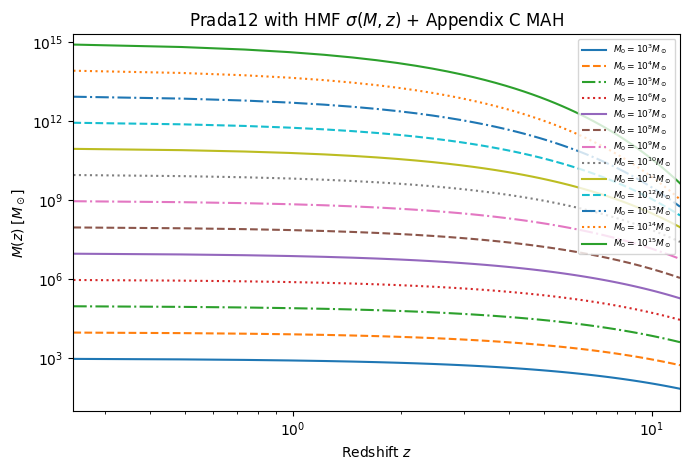

In [7]:
prada_figure, prada_axis = plt.subplots(figsize=(7.0, 4.8))

for index, mass0_msun in enumerate(present_day_masses_msun):
    exponent = int(np.log10(mass0_msun))
    prada_axis.plot(
        redshift[positive_redshift],
        prada_hmf_mass_tracks_msun[index, positive_redshift],
        linestyle=line_styles[index % len(line_styles)],
        label=rf"$M_0=10^{{{exponent}}}M_\odot$",
    )

prada_axis.set_xscale("log")
prada_axis.set_yscale("log")
prada_axis.set_xlim(redshift[1], 12.0)
prada_axis.set_ylim(1.0e1, 2.0e15)
prada_axis.set_yticks(10.0 ** np.arange(3.0, 16.0, 3.0))
prada_axis.set_xlabel(r"Redshift $z$")
prada_axis.set_ylabel(r"$M(z)\;[M_\odot]$")
prada_axis.set_title(r"Prada12 with HMF $\sigma(M,z)$ + Appendix C MAH")
prada_axis.legend(
    loc="upper right",
    fontsize=6.5,
    handlelength=2.7,
    labelspacing=0.25,
)

prada_figure.tight_layout()
prada_figure_path = PROJECT_ROOT / "fig9_prada12_hmf_sigma.png"
prada_figure.savefig(prada_figure_path, dpi=220)
print(f"新 Prada12 图片已保存：{prada_figure_path}")
plt.show()

## 8. 导出新 Prada12 曲线与吸积参数

第一个 CSV 保存 13 条 $M(z)$ 曲线；第二个 CSV 保存每条曲线使用的 $C(M_0,0)$、$z_{-2}$、$\alpha$ 和 $\beta$，用于追踪模型调用结果。

In [8]:
prada_csv_path = PROJECT_ROOT / "fig9_prada12_hmf_sigma.csv"
np.savetxt(
    prada_csv_path,
    np.column_stack((redshift, prada_hmf_mass_tracks_msun.T)),
    delimiter=",",
    header=",".join(["z", *mass_columns]),
    comments="",
)

# mass_accretion_parameters 每行依次返回 z_minus2、alpha、beta。
parameter_rows = np.column_stack((
    present_day_masses_msun,
    prada_hmf_concentrations_z0,
    prada_hmf_parameters,
))
prada_parameter_path = PROJECT_ROOT / "fig9_prada12_hmf_sigma_parameters.csv"
np.savetxt(
    prada_parameter_path,
    parameter_rows,
    delimiter=",",
    header="M0_msun,concentration_z0,z_minus2,alpha,beta",
    comments="",
)

print(f"新 Prada12 曲线数据已保存：{prada_csv_path}")
print(f"新 Prada12 吸积参数已保存：{prada_parameter_path}")

新 Prada12 曲线数据已保存：D:\pbh formation\pbh merge\2body channel and numerical simulation\fig9_prada12_hmf_sigma.csv
新 Prada12 吸积参数已保存：D:\pbh formation\pbh merge\2body channel and numerical simulation\fig9_prada12_hmf_sigma_parameters.csv


## 9. 当前复现边界

本图严格使用项目中已经实现的 Ludlow16/Appendix C 质量吸积参数。当前公式在高质量端会出现原论文 Fig. 9 没有显示的轨迹交叉，尤其涉及 $10^{13}$–$10^{15} M_\odot$。现有证据只说明论文原图在高质量端可能采用了未公开的参数处理，尚不能把这种差异解释成另一种已确认的物理模型。

新增的 Prada12 曲线使用 `prada12_hmf_sigma` 在 $z=0$ 重新求浓度，再将该浓度送入同一套 Appendix C 质量吸积公式。它不是 Prada12 论文单独校准的质量吸积模型，而是“新 Prada 浓度 + 本文 Appendix C 吸积参数”的组合。

两组曲线都保留固定 $M_0$ 的轨迹身份，不通过逐红移排序来人为消除交叉。